# **Titanic Survival Prediction: An End-to-End Machine Learning Workflow**

A practical machine learning classification project using the Titanic dataset, developed in Python with pandas and scikit-learn.

**Workflow:**
Data Understanding → Exploratory Data Analysis → Feature Selection → Preprocessing → Model Development → Cross-Validation → Hyperparameter Tuning → Model Selection → Held-Out Test Evaluation

## **1. Project Overview**

This project demonstrates an end-to-end machine learning workflow for predicting passenger survival using the Titanic dataset.

The analysis focuses on building a reproducible classification workflow in Python, including exploratory data analysis, feature selection, prevention of data leakage, missing-value handling, categorical encoding, feature scaling, model development, cross-validation, hyperparameter experimentation, model comparison, and final evaluation on a held-out test set.

Five classification algorithms were evaluated:

* Logistic Regression
* Decision Tree
* Random Forest
* K-Nearest Neighbors (KNN)
* Gradient Boosting

Gradient Boosting was selected as the candidate final model based on its cross-validation performance, particularly its ROC-AUC. The selected model was subsequently evaluated once on an untouched test set to assess its performance on unseen data.

# **2. Dataset and Problem Definition**
**Dataset**

The project uses the Titanic dataset, which contains passenger-level information including demographic characteristics, ticket class, family-related variables, fare, and port of embarkation. The dataset contains **891 observations and 15 variables.**

**Problem Definition**

The objective is to develop a binary classification model to predict whether a passenger survived the Titanic disaster.

* Target variable: survived
   * 0 = Did not survive
  *   1 = Survived

The initial predictor variables selected for modelling were: **pclass, sex, age, sibsp, parch, fare, and embarked.**

The project treats the prediction task as a supervised binary classification problem.

# **3. Data Understanding**

The dataset was first examined to understand its structure, variable types, missing values, and target distribution before beginning model development.

The main checks included:

* Dataset dimensions
* Variable data types
* Missing values
* Unique values for categorical variables
* Summary statistics
* Distribution of the target variable

These initial checks were used to identify data-quality issues and inform subsequent preprocessing and feature-selection decisions.

**Lesson 1 — Getting to Know the Dataset**

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv")

In [3]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [5]:
df.shape

(891, 15)

In [6]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [8]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [9]:
df["survived"].value_counts()

,count
survived,
0,549
1,342


In [10]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Lesson 2 — Understanding the Variables Before Modeling**

In [11]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object


In [12]:
df["pclass"].unique()

array([3, 1, 2])

In [13]:
df["sex"].unique()

array(['male', 'female'], dtype=object)

In [14]:
df.nunique()

,0
survived,2
pclass,3
sex,2
age,88
sibsp,7
parch,7
fare,248
embarked,3
class,3
who,3


In [15]:
df["survived"].value_counts()

,count
survived,
0,549
1,342


In [16]:
df["survived"].value_counts(normalize=True)

,proportion
survived,
0,0.616162
1,0.383838


# **4. Exploratory Data Analysis**

Exploratory data analysis was performed to understand the distribution of the target variable and examine relationships between passenger characteristics and survival.

The analysis focused on:

* Survival distribution
* Survival by sex
* Survival by passenger class
* Survival by age
* Fare distribution
* Family-related variables (sibsp and parch)
* Embarkation port
* Missing-data patterns

The EDA was used to identify potentially informative predictors and understand important characteristics of the dataset before model development.

**4.1 Survival by Sex**

In [17]:
df.groupby("sex")["survived"].mean() ##Survival proportion by sex.

,survived
sex,
female,0.742038
male,0.188908


In [18]:
df["sex"].value_counts()

,count
sex,
male,577
female,314


In [19]:
pd.crosstab(df["sex"], df["survived"]) ##tsurvival he underlying counts from which those proportions can be calculated.

survived,0,1
sex,,
female,81,233
male,468,109


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

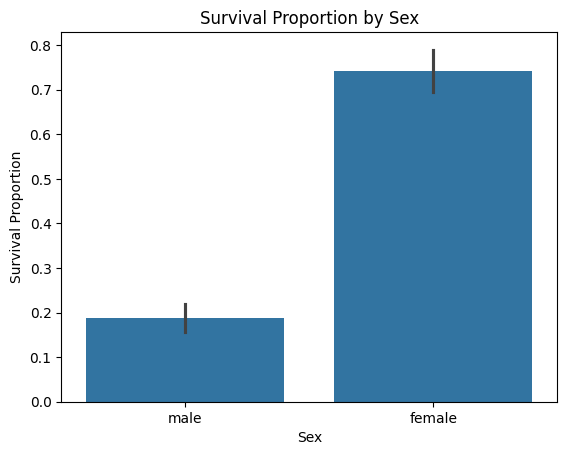

In [21]:
sns.barplot(data=df,x="sex",y="survived")
plt.ylabel("Survival Proportion")
plt.xlabel("Sex")
plt.title("Survival Proportion by Sex")
plt.show()

**4.2 Survival by Passenger Class**

In [22]:
df["pclass"].value_counts().sort_index()

,count
pclass,
1,216
2,184
3,491


In [23]:
df.groupby("pclass")["survived"].mean()

,survived
pclass,
1,0.629630
2,0.472826
3,0.242363


In [24]:
pd.crosstab(df["sex"], df["pclass"])

pclass,1,2,3
sex,,,
female,94,76,144
male,122,108,347


In [25]:
pd.crosstab(df["sex"], df["pclass"], normalize="index")

pclass,1,2,3
sex,,,
female,0.299363,0.242038,0.458599
male,0.211438,0.187175,0.601386


In [26]:
df.groupby(["pclass","sex"])["survived"].mean() ##“Within each passenger class,how does survival differ between males and females?

pclass  sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: survived, dtype: float64

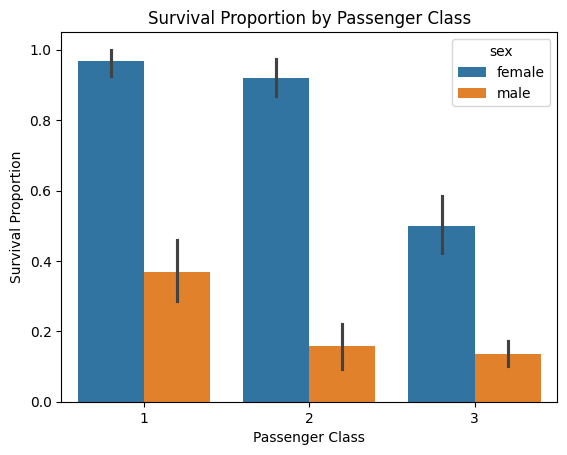

In [27]:
sns.barplot(data=df,x="pclass",y="survived", hue="sex") ##x-axis→passenger class,y-axis→survival proportion, hue→separate males and females
plt.ylabel("Survival Proportion")
plt.xlabel("Passenger Class")
plt.title("Survival Proportion by Passenger Class")
plt.show()

**4.3 Age Distribution and Survival**


In [28]:
df["age"].describe()

,age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


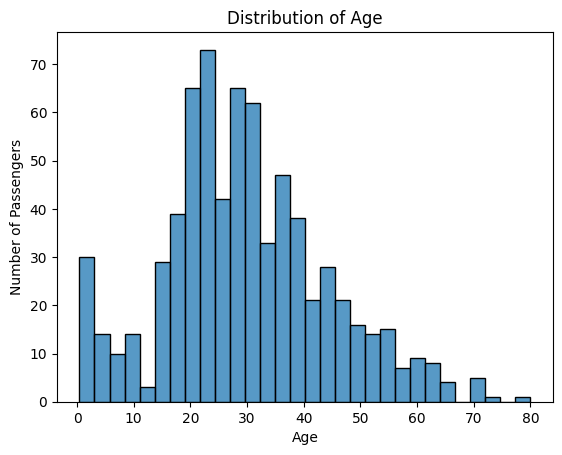

In [29]:
sns.histplot(data=df,x="age", bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

In [30]:
df.groupby("survived")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
survived,,,,,,,,
0,424.0,30.626179,14.172110,1.00,21.0,28.0,39.0,74.0
1,290.0,28.343690,14.950952,0.42,19.0,28.0,36.0,80.0


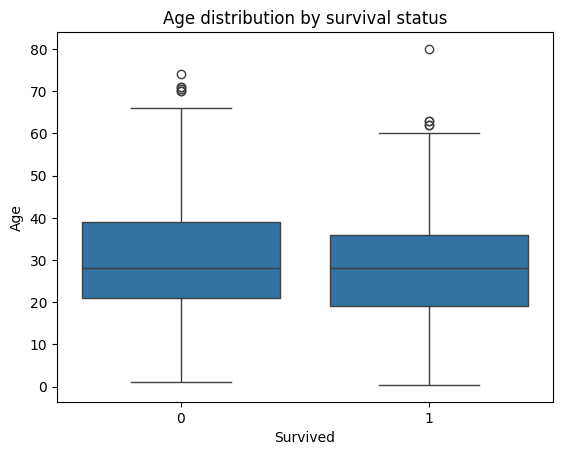

In [31]:
sns.boxplot(data=df, x="survived", y="age")

plt.xlabel("Survived")
plt.ylabel("Age")
plt.title("Age distribution by survival status")
plt.show()

In [32]:
df["age_group"]=pd.cut(df["age"], bins=[0,10,20,30,40,50,60,80])

In [33]:
df["age_group"].value_counts().sort_index()

,count
age_group,
"(0, 10]",64
"(10, 20]",115
"(20, 30]",230
"(30, 40]",155
"(40, 50]",86
"(50, 60]",42
"(60, 80]",22


In [34]:
df.groupby("age_group",observed=True)["survived"].mean()

,survived
age_group,
"(0, 10]",0.593750
"(10, 20]",0.382609
"(20, 30]",0.365217
"(30, 40]",0.445161
"(40, 50]",0.383721
"(50, 60]",0.404762
"(60, 80]",0.227273


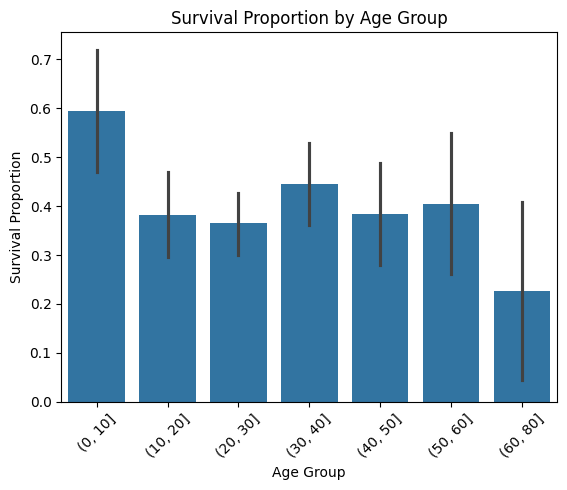

In [35]:
sns.barplot(data=df,x="age_group",y="survived")
plt.ylabel("Survival Proportion")
plt.xlabel("Age Group")
plt.title("Survival Proportion by Age Group")
plt.xticks(rotation=45)
plt.show()

**4.4 Fare Distribution and Survival**

In [36]:
df["fare"].describe()

,fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


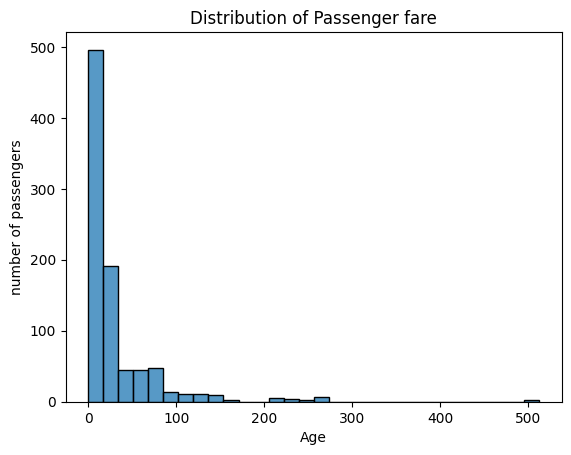

In [37]:
sns.histplot(data=df, x="fare", bins=30)
plt.xlabel("Age")
plt.ylabel("number of passengers")
plt.title("Distribution of Passenger fare")
plt.show()

In [38]:
df.groupby("survived")["fare"].describe()

,count,mean,std,min,25%,50%,75%,max
survived,,,,,,,,
0,549.0,22.117887,31.388207,0.0,7.8542,10.5,26.0,263.0000
1,342.0,48.395408,66.596998,0.0,12.4750,26.0,57.0,512.3292


In [39]:
df.groupby("pclass")["fare"].describe()

,count,mean,std,min,25%,50%,75%,max
pclass,,,,,,,,
1,216.0,84.154687,78.380373,0.0,30.92395,60.2875,93.5,512.3292
2,184.0,20.662183,13.417399,0.0,13.00000,14.2500,26.0,73.5000
3,491.0,13.675550,11.778142,0.0,7.75000,8.0500,15.5,69.5500


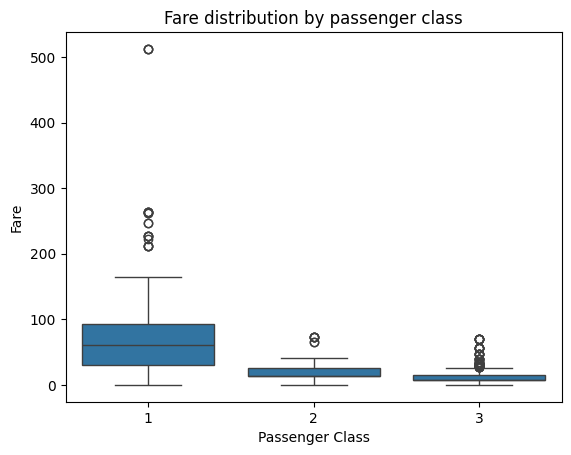

In [40]:
sns.boxplot(data=df,x="pclass",y="fare")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.title("Fare distribution by passenger class")
plt.show()

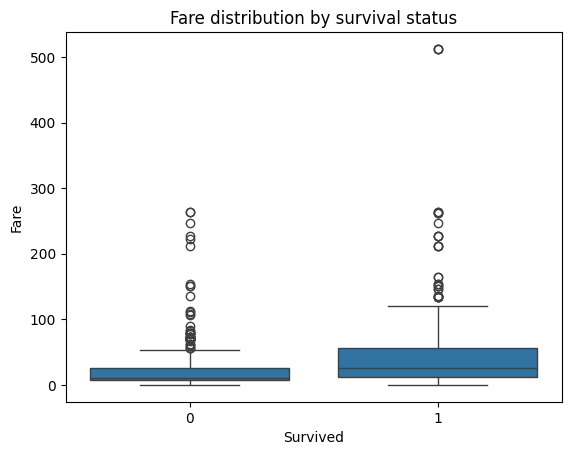

In [41]:
sns.boxplot(data=df,x="survived",y="fare")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.title("Fare distribution by survival status")
plt.show()

**4.5 Family-Related Variables**

The relationship between traveling alone and survival was also explored as part of the exploratory analysis. This derived variable was not included in the final predictor set.

In [42]:
df["sibsp"].describe() ##use describe when the variable is numeric

,sibsp
count,891.000000
mean,0.523008
std,1.102743
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,8.000000


In [43]:
df["sibsp"].value_counts().sort_index() ##use value_count when the variable is discrete numerical

,count
sibsp,
0,608
1,209
2,28
3,16
4,18
5,5
8,7


In [44]:
df.groupby("sibsp")["survived"].agg(["count", "mean"]) ##here mean is the percentage of survival;

,count,mean
sibsp,,
0,608,0.345395
1,209,0.535885
2,28,0.464286
3,16,0.250000
4,18,0.166667
5,5,0.000000
8,7,0.000000


In [45]:
df["parch"].describe()

,parch
count,891.000000
mean,0.381594
std,0.806057
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,6.000000


In [46]:
df["parch"].value_counts().sort_index()

,count
parch,
0,678
1,118
2,80
3,5
4,4
5,5
6,1


In [47]:
df.groupby("parch")["survived"].agg(["count", "mean"]) #survived is coded 0/1, the mean column represents the observed survival proportion within each parch category

,count,mean
parch,,
0,678,0.343658
1,118,0.550847
2,80,0.500000
3,5,0.600000
4,4,0.000000
5,5,0.200000
6,1,0.000000


In [48]:
df["alone"].value_counts()

,count
alone,
True,537
False,354


In [49]:
pd.crosstab(
    df["alone"],
    [df["sibsp"], df["parch"]]
)

sibsp    0                     1             ...  2        3        4     5  8
parch    0   1   2  3  4  5    0   1   2  3  ...  1  2  3  0  1  2  1  2  2  2
alone                                        ...                              
False    0  38  29  1  1  2  123  57  19  3  ...  7  4  1  2  7  7  9  9  5  7
True   537   0   0  0  0  0    0   0   0  0  ...  0  0  0  0  0  0  0  0  0  0

[2 rows x 24 columns]

In [50]:
pd.crosstab(
    df["alone"],
    (df["sibsp"] + df["parch"])
)

col_0,0,1,2,3,4,5,6,7,10
alone,,,,,,,,,
False,0,161,102,29,15,22,12,6,7
True,537,0,0,0,0,0,0,0,0


In [51]:
df.groupby("alone")["survived"].agg(["count", "mean"])

,count,mean
alone,,
False,354,0.505650
True,537,0.303538


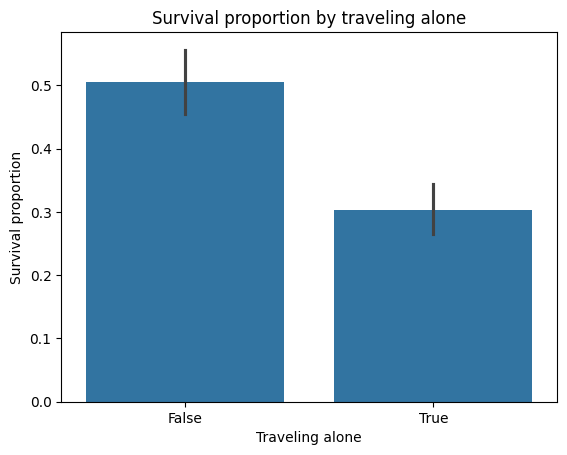

In [52]:
sns.barplot(
    data=df,
    x="alone",
    y="survived"
)

plt.xlabel("Traveling alone")
plt.ylabel("Survival proportion")
plt.title("Survival proportion by traveling alone")
plt.show()

**4.6 Embarkation Port**

The distribution of passengers across embarkation ports was examined to understand the composition of the dataset and potential differences in survival.

In [53]:
df["embarked"].value_counts()

,count
embarked,
S,644
C,168
Q,77


In [54]:
df.groupby("embarked")["survived"].agg(["count", "mean"])

,count,mean
embarked,,
C,168,0.553571
Q,77,0.389610
S,644,0.336957


In [55]:
from numpy.random.mtrand import normal ##dont know the reason
pd.crosstab(df["embarked"],df["pclass"], normalize="index")


pclass,1,2,3
embarked,,,
C,0.505952,0.101190,0.392857
Q,0.025974,0.038961,0.935065
S,0.197205,0.254658,0.548137


In [56]:
pd.crosstab(df["embarked"], df["sex"], normalize="index")

sex,female,male
embarked,,
C,0.434524,0.565476
Q,0.467532,0.532468
S,0.315217,0.684783


In [57]:
pd.crosstab([df["embarked"], df["sex"]],df["survived"],normalize="index")

survived                0         1
embarked sex                       
C        female  0.123288  0.876712
         male    0.694737  0.305263
Q        female  0.250000  0.750000
         male    0.926829  0.073171
S        female  0.310345  0.689655
         male    0.825397  0.174603

In [58]:
df[df["embarked"].isna()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,"(30, 40]"
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,"(60, 80]"


In [59]:
df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2


**4.7 Passenger Type**

The distribution of passengers by demographic category (who) was examined to understand the composition of the dataset and its potential relationship with survival.

In [60]:
df["who"].value_counts()

,count
who,
man,537
woman,271
child,83


In [61]:
df.groupby("who")["survived"].agg(["count", "mean"])

,count,mean
who,,
child,83,0.590361
man,537,0.163873
woman,271,0.756458


In [62]:
pd.crosstab(
    df["who"],
    [df["survived"]]
)

survived,0,1
who,,
child,34,49
man,449,88
woman,66,205


In [63]:
pd.crosstab(
    df["who"],
    [df["survived"], df["sex"]]
)

survived      0           1     
sex      female male female male
who                             
child        15   19     28   21
man           0  449      0   88
woman        66    0    205    0

In [64]:
pd.crosstab(df["who"], df["sex"], normalize="index")

sex,female,male
who,,
child,0.518072,0.481928
man,0.000000,1.000000
woman,1.000000,0.000000


In [65]:
df.groupby("who")["survived"].agg(["count","mean"])

,count,mean
who,,
child,83,0.590361
man,537,0.163873
woman,271,0.756458


In [66]:
pd.crosstab(df["who"], df["age"].isna())

age,False,True
who,,
child,83,0
man,413,124
woman,218,53


### 4.8 Deck Type ####

In [67]:
df["deck"].value_counts()

,count
deck,
C,59
B,47
D,33
E,32
A,15
F,13
G,4


In [68]:
df["deck"].isna().sum()

np.int64(688)

In [69]:
df["deck"].value_counts(dropna=False)

,count
deck,
NaN,688
C,59
B,47
D,33
E,32
A,15
F,13
G,4


In [70]:
pd.crosstab(df["pclass"], df["deck"], normalize="index")

deck,A,B,C,D,E,F,G
pclass,,,,,,,
1,0.085714,0.268571,0.337143,0.165714,0.142857,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.250000,0.250000,0.500000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.250000,0.416667,0.333333


In [71]:
df.groupby("deck")["survived"].agg(["count","mean"])

,count,mean
deck,,
A,15,0.466667
B,47,0.744681
C,59,0.593220
D,33,0.757576
E,32,0.750000
F,13,0.615385
G,4,0.500000


**4.9 Survival by Passenger Class and Sex**

The joint relationship between passenger class and sex was examined to assess whether survival patterns differed across these two characteristics.

In [72]:
df.groupby(["pclass","sex"])["survived"].agg(["count","mean"])

count      mean
pclass sex                    
1      female     94  0.968085
       male      122  0.368852
2      female     76  0.921053
       male      108  0.157407
3      female    144  0.500000
       male      347  0.135447

In [73]:
pd.crosstab(
    [df["pclass"], df["sex"]],
    df["survived"]
)

survived         0   1
pclass sex            
1      female    3  91
       male     77  45
2      female    6  70
       male     91  17
3      female   72  72
       male    300  47

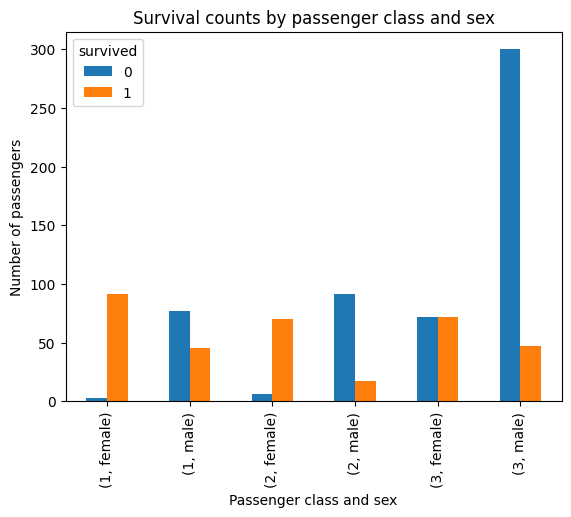

In [74]:
pd.crosstab(
    [df["pclass"], df["sex"]],
    df["survived"]
).plot(kind="bar")

plt.ylabel("Number of passengers")
plt.xlabel("Passenger class and sex")
plt.title("Survival counts by passenger class and sex")
plt.show()

**4.10 Derived Variables**

Derived variables were examined during EDA to understand the dataset structure and identify variables that may contain information already represented by other predictors.

In [75]:
df["adult_male"].value_counts()

,count
adult_male,
True,537
False,354


In [76]:
pd.crosstab(df["adult_male"], df["sex"])

sex,female,male
adult_male,,
False,314,40
True,0,537


In [77]:
pd.crosstab(df["adult_male"], df["who"])

who,child,man,woman
adult_male,,,
False,83,0,271
True,0,537,0


In [78]:
df.groupby("adult_male")["survived"].agg(["count","mean"])

,count,mean
adult_male,,
False,354,0.717514
True,537,0.163873


In [79]:
df.groupby("alone")["survived"].agg(["count", "mean"])

,count,mean
alone,,
False,354,0.505650
True,537,0.303538


In [80]:
df.groupby("embarked")["survived"].agg(["count", "mean"])

,count,mean
embarked,,
C,168,0.553571
Q,77,0.389610
S,644,0.336957


In [81]:
pd.crosstab(
    df["embarked"],
    df["pclass"],
    normalize="index"
)

pclass,1,2,3
embarked,,,
C,0.505952,0.101190,0.392857
Q,0.025974,0.038961,0.935065
S,0.197205,0.254658,0.548137


In [82]:
pd.crosstab(df["embarked"], df["embark_town"])

embark_town,Cherbourg,Queenstown,Southampton
embarked,,,
C,168,0,0
Q,0,77,0
S,0,0,644


**4.11 Missing Data Patterns**

In [83]:
df["deck_missing"]=df["deck"].isna()

In [84]:
pd.crosstab(df["pclass"], df["deck_missing"],normalize="index")

deck_missing,False,True
pclass,,
1,0.810185,0.189815
2,0.086957,0.913043
3,0.024440,0.975560


In [85]:
df["deck"].value_counts(dropna=False)

,count
deck,
NaN,688
C,59
B,47
D,33
E,32
A,15
F,13
G,4


In [86]:
df.groupby(df["age"].isna())["survived"].agg(["count","mean"])

,count,mean
age,,
False,714,0.406162
True,177,0.293785


In [87]:
df.groupby("deck_missing")["survived"].agg(["count", "mean"])

,count,mean
deck_missing,,
False,203,0.669951
True,688,0.299419


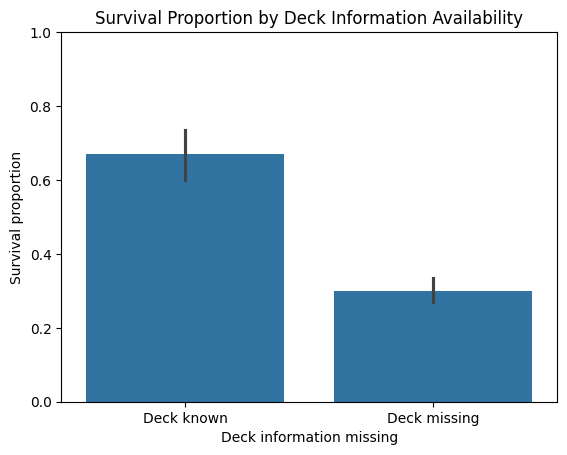

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=df,
    x="deck_missing",
    y="survived"
)

plt.xlabel("Deck information missing")
plt.ylabel("Survival proportion")
plt.title("Survival Proportion by Deck Information Availability")

plt.xticks(
    [0, 1],
    ["Deck known", "Deck missing"]
)

plt.ylim(0, 1)
plt.show()

**4.11 Correlation Among Numeric Variables**

Correlations among the main numeric variables were examined to identify potential linear associations and possible redundancy among predictors.



In [89]:
df[["age","sibsp","parch","fare"]].corr()

,age,sibsp,parch,fare
age,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.308247,1.000000,0.414838,0.159651
parch,-0.189119,0.414838,1.000000,0.216225
fare,0.096067,0.159651,0.216225,1.000000


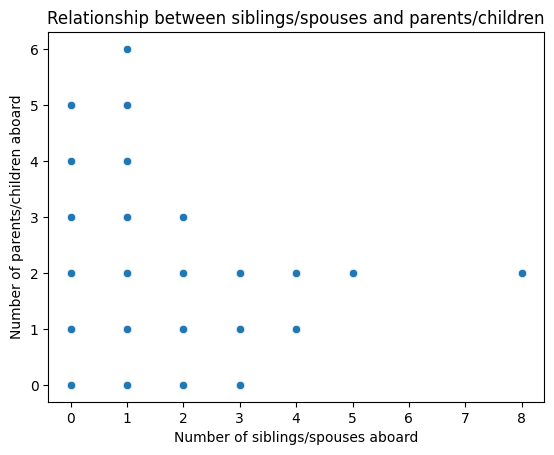

In [90]:
sns.scatterplot(data=df,x="sibsp",y="parch")
plt.xlabel("Number of siblings/spouses aboard")
plt.ylabel("Number of parents/children aboard")
plt.title("Relationship between siblings/spouses and parents/children")
plt.show()

# **5. Feature Selection and Leakage Assessment**

Based on the exploratory analysis and the structure of the dataset, a final set of predictors was defined for model development.

The selected predictors were:

**pclass, sex, age, sibsp, parch, fare, and embarked.**

Variables such as alive were excluded because they directly represent the target outcome and would cause data leakage. Other variables, including class, embark_town, who, adult_male, alone, and deck, were excluded because they were redundant, derived from other predictors, or had substantial missingness.

The target variable was survived, representing whether the passenger survived.

In [91]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]

X = df[features]
y = df["survived"]

In [92]:
X.shape


(891, 7)

In [93]:
y.shape

(891,)

**6. Train-Test Split**

The dataset was divided into training and test sets before fitting any preprocessing steps or machine learning models.

The training set was used for model development, cross-validation, and hyperparameter experimentation, while the test set was kept untouched until the final evaluation to provide an unbiased estimate of performance on unseen data.

In [94]:
from sklearn.model_selection import train_test_split

In [95]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [96]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((712, 7), (179, 7), (712,), (179,))

In [97]:
y_train.value_counts(normalize=True)

,proportion
survived,
0,0.616573
1,0.383427


In [98]:
y_test.value_counts(normalize=True)

,proportion
survived,
0,0.614525
1,0.385475


Next we are imputing the age missing value with the train median, then apply it to test set. As, it is numerical coding is not needed.

# **7. Preprocessing Pipeline**

The selected predictors contain both numerical and categorical variables, as well as missing values. A preprocessing pipeline was therefore constructed to handle these requirements consistently.

The preprocessing steps included:

Median imputation for numerical variables
Most-frequent imputation for categorical variables
Standardization of numerical variables
One-hot encoding of categorical variables

All preprocessing steps were incorporated into a scikit-learn pipeline so that they were learned only from the training data and applied consistently during cross-validation and final evaluation.

In [99]:
from sklearn.impute import SimpleImputer

**7.1 Numerical Missing-Value Imputation**

Missing values in numerical variables were handled using median imputation. The imputation value was learned from the training data only and then applied to both the training and test sets to avoid data leakage.

age was used to demonstrate this process before incorporating the same logic into the complete preprocessing pipeline.

In [100]:
imputer=SimpleImputer(strategy="median")

In [101]:
imputer.fit(X_train[["age"]])

SimpleImputer(strategy='median')

In [102]:
imputer.statistics_

array([28.5])

In [103]:
age_train_imputed=imputer.transform(X_train[["age"]])

In [104]:
age_train_imputed[:10]

array([[28.5],
       [28.5],
       [28.5],
       [18. ],
       [31. ],
       [21. ],
       [26. ],
       [28.5],
       [28.5],
       [31. ]])

In [105]:
age_test_imputed=imputer.transform(X_test[["age"]])

In [106]:
age_test_imputed[:10]

array([[24. ],
       [44. ],
       [22. ],
       [41. ],
       [28.5],
       [36. ],
       [36. ],
       [45. ],
       [49. ],
       [34. ]])

In [107]:
X_train["sex"].head()

,sex
692,male
481,male
527,male
855,female
801,female


**7.2 Categorical Variable Encoding**

Categorical variables cannot be used directly by most scikit-learn machine learning models in their original text form. One-hot encoding was therefore used to convert categorical values into numerical indicator variables.

**sex** was used to demonstrate how categorical encoding works before incorporating the transformation into the complete preprocessing pipeline.

For "Sex" we have no missing value. Hence, no imputation is needed but as it is categorical variable we need to code it like one hot coding.

In [108]:
from sklearn.preprocessing import OneHotEncoder

In [109]:
encoder=OneHotEncoder()

In [110]:
encoder.fit(X_train[["sex"]])

OneHotEncoder()

In [111]:
encoder.categories_

[array(['female', 'male'], dtype=object)]

In [112]:
sex_train_encoded = encoder.transform(X_train[["sex"]])

In [113]:
sex_train_encoded[:10]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10 stored elements and shape (10, 2)>

In [114]:
sex_train_encoded.toarray()

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [1., 0.],
       [0., 1.],
       [0., 1.]])

In [115]:
from sklearn.impute import SimpleImputer

In [116]:
embarked_imputer = SimpleImputer(strategy="most_frequent")

In [117]:
embarked_imputer.fit(X_train[["embarked"]])

SimpleImputer(strategy='most_frequent')

In [118]:
embarked_imputer.statistics_

array(['S'], dtype=object)

In [119]:
embarked_train_imputed = embarked_imputer.transform(X_train[["embarked"]])

In [120]:
embarked_train_imputed[:10]

array([['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S'],
       ['C'],
       ['Q'],
       ['S']], dtype=object)

In [121]:
embarked_test_imputed = embarked_imputer.transform(X_test[["embarked"]])

In [122]:
pd.Series(embarked_train_imputed.ravel()).value_counts()

,count
S,518
C,139
Q,55


In [123]:
from sklearn.preprocessing import OneHotEncoder

In [124]:
embarked_encoder = OneHotEncoder()

In [125]:
embarked_encoder.fit(embarked_train_imputed)

OneHotEncoder()

In [126]:
embarked_encoder.categories_

[array(['C', 'Q', 'S'], dtype=object)]

In [127]:
embarked_train_encoded = embarked_encoder.transform( embarked_train_imputed)

In [128]:
embarked_train_encoded[:10].toarray()

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [129]:
embarked_test_imputed = embarked_imputer.transform(X_test[["embarked"]])

In [130]:
embarked_test_encoded = embarked_encoder.transform(embarked_test_imputed)

In [131]:
embarked_test_encoded[:10].toarray()

array([[0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.]])

**7.3 Building the Preprocessing Pipeline**

After demonstrating the individual preprocessing steps, separate preprocessing workflows were defined for numerical and categorical predictors.

The numerical variables were assigned median imputation, while the categorical variables were handled separately because they require categorical-specific preprocessing.

At this stage, the preprocessing pipelines define the transformation steps but have not yet been applied to any columns. The columns are assigned later using ColumnTransformer.

In [132]:
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]

In [133]:
categorical_features = ["sex", "embarked"]

In [134]:
numeric_features

['pclass', 'age', 'sibsp', 'parch', 'fare']

In [135]:
from sklearn.pipeline import Pipeline

In [136]:
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]) ##we have only created a set of instructions.We have not told it which columns to use.

now for categorical variable; sex and embarked. as before we will first impute with the mode then will use encoder.

In [137]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))  ###"If the encoder encounters a category during prediction that was not present in the training data,
                                                              ##don't raise an error. Just encode all known-category columns as 0 and continue." ✅
    ]
)

In [138]:
from sklearn.compose import ColumnTransformer

In [139]:
preprocessor= ColumnTransformer(
 transformers=[
     ("num",numeric_transformer,numeric_features),
     ("cat",categorical_transformer,categorical_features)
 ]
)

till now preprocessor is the set of instructions. it hasn't yet learned anything. now we'll assign it to x_train to fit  

In [140]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['pclass', 'age', 'sibsp', 'parch', 'fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'embarked'])])

In [141]:
preprocessor.named_transformers_["num"] ##means: "Give me the transformer that I called num."

Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])

In [142]:
preprocessor.named_transformers_["num"].named_steps["imputer"].statistics_

array([ 3.    , 28.5   ,  0.    ,  0.    , 14.4542])

In [143]:
preprocessor.named_transformers_["cat"].named_steps["imputer"].statistics_

array(['male', 'S'], dtype=object)

In [144]:
preprocessor.named_transformers_["cat"].named_steps["onehot"].categories_

[array(['female', 'male'], dtype=object), array(['C', 'Q', 'S'], dtype=object)]

In [145]:
X_train_processed = preprocessor.transform(X_train)

In [146]:
X_train_processed.shape

(712, 10)

In [147]:
feature_names = preprocessor.get_feature_names_out()

In [148]:
feature_names

array(['num__pclass', 'num__age', 'num__sibsp', 'num__parch', 'num__fare',
       'cat__sex_female', 'cat__sex_male', 'cat__embarked_C',
       'cat__embarked_Q', 'cat__embarked_S'], dtype=object)

In [149]:
X_train_processed[:5]

array([[  3.    ,  28.5   ,   0.    ,   0.    ,  56.4958,   0.    ,
          1.    ,   0.    ,   0.    ,   1.    ],
       [  2.    ,  28.5   ,   0.    ,   0.    ,   0.    ,   0.    ,
          1.    ,   0.    ,   0.    ,   1.    ],
       [  1.    ,  28.5   ,   0.    ,   0.    , 221.7792,   0.    ,
          1.    ,   0.    ,   0.    ,   1.    ],
       [  3.    ,  18.    ,   0.    ,   1.    ,   9.35  ,   1.    ,
          0.    ,   0.    ,   0.    ,   1.    ],
       [  2.    ,  31.    ,   1.    ,   1.    ,  26.25  ,   1.    ,
          0.    ,   0.    ,   0.    ,   1.    ]])

In [150]:
X_test_processed=  preprocessor.transform(X_test)

In [151]:
X_test_processed.shape

(179, 10)

In [152]:
X_train_processed.shape

(712, 10)

In [153]:
X_test_processed[:5]

array([[ 3.    , 24.    ,  2.    ,  0.    , 24.15  ,  0.    ,  1.    ,
         0.    ,  0.    ,  1.    ],
       [ 3.    , 44.    ,  0.    ,  1.    , 16.1   ,  0.    ,  1.    ,
         0.    ,  0.    ,  1.    ],
       [ 3.    , 22.    ,  0.    ,  0.    ,  7.225 ,  0.    ,  1.    ,
         1.    ,  0.    ,  0.    ],
       [ 3.    , 41.    ,  2.    ,  0.    , 14.1083,  0.    ,  1.    ,
         0.    ,  0.    ,  1.    ],
       [ 3.    , 28.5   ,  1.    ,  0.    , 15.5   ,  1.    ,  0.    ,
         0.    ,  1.    ,  0.    ]])

In [154]:
import numpy as np

In [155]:
np.isnan(X_test_processed).sum() ##no missing value in test set

np.int64(0)

In [156]:
np.isnan(X_train_processed).sum() ##no missing value in training set

np.int64(0)

In [157]:
X_train_processed.shape, X_test_processed.shape

((712, 10), (179, 10))

In [158]:
X_train.isna().sum()

,0
pclass,0
sex,0
age,137
sibsp,0
parch,0
fare,0
embarked,2


## **8. Model Development**

Five classification algorithms were evaluated using the same preprocessing workflow. Each model was integrated with the preprocessing pipeline so that preprocessing was performed consistently within the model-fitting process and during cross-validation.

**8.1 Logistic Regression**

Logistic Regression was used as a baseline linear classification model.

In [159]:
from sklearn.linear_model import LogisticRegression

In [160]:
logistic_model=LogisticRegression()

In [161]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logistic_model)
    ]
)

In [162]:
from sklearn.model_selection import cross_val_score

In [163]:
cv_scores = cross_val_score(
    model_pipeline,
    X_train,
    y_train,
    cv=5
)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [164]:
cv_scores

array([0.8041958 , 0.75524476, 0.8028169 , 0.81690141, 0.80985915])

**Addressing Convergence in Logistic Regression**

The initial Logistic Regression model was evaluated using the preprocessing pipeline without feature scaling. The cross-validation process produced convergence warnings, indicating that the optimization algorithm was having difficulty reaching a stable solution.

Because the numerical predictors have different scales, the numerical preprocessing pipeline was updated to include standardization.

In [165]:
from sklearn.preprocessing import StandardScaler

In [166]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

**8.1 Logistic Regression — Updated preprocessing with scalling**

In [167]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [168]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logistic_model)
    ]
)

In [169]:
cv_scores= cross_val_score(model_pipeline,X_train,y_train,cv=5)  ##now the convergence warning is gone. ✅

**8.2 Cross-Validation Performance**

Five-fold cross-validation was used to estimate Logistic Regression performance on the training data. The mean cross-validation accuracy was used as an initial measure of model performance.

In [170]:
cv_scores

array([0.79020979, 0.76223776, 0.8028169 , 0.81690141, 0.80985915])

In [171]:
cv_scores.mean()

np.float64(0.796405003447257)

**8.3 Model Inspection**

In [172]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('model', LogisticRegression())])

In [173]:
model_pipeline.named_steps["model"].coef_

array([[-0.92197224, -0.50281488, -0.2606066 , -0.06642413,  0.10026908,
         1.29944383, -1.32071816,  0.03224661,  0.30478416, -0.3583051 ]])

In [174]:
model_pipeline.named_steps["model"].intercept_

array([-0.03346059])

In [175]:
model_pipeline.named_steps["model"].classes_

array([0, 1])

In [176]:
model_pipeline.predict_proba(X_train[:5])

array([[0.90315975, 0.09684025],
       [0.77625112, 0.22374888],
       [0.41923218, 0.58076782],
       [0.35087369, 0.64912631],
       [0.26712248, 0.73287752]])

In [177]:
model_pipeline.predict(X_train[:5])

array([0, 0, 1, 1, 1])

**8.4 Out-of-Fold Predictions and Evaluation**

In [178]:
from sklearn.model_selection import cross_val_predict

In [179]:
cv_predictions = cross_val_predict(
    model_pipeline,
    X_train,
    y_train,
    cv=5
)

In [180]:
cv_predictions[:20]

array([0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

In [181]:
from sklearn.metrics import confusion_matrix

In [182]:
cm = confusion_matrix(y_train, cv_predictions)
cm

array([[375,  64],
       [ 81, 192]])

In [183]:
from sklearn.metrics import recall_score

In [184]:
recall_score(y_train, cv_predictions)

0.7032967032967034

In [185]:
from sklearn.metrics import precision_score   ##Of all the passengers the model predicted would survive, how many actually survived?

In [186]:
precision_score(y_train, cv_predictions)

0.75

In [187]:
from sklearn.metrics import f1_score

In [188]:
f1_score(y_train, cv_predictions)

0.725897920604915

In [189]:
from sklearn.metrics import classification_report

In [190]:
print(classification_report(y_train, cv_predictions))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       439
           1       0.75      0.70      0.73       273

    accuracy                           0.80       712
   macro avg       0.79      0.78      0.78       712
weighted avg       0.79      0.80      0.80       712



**8.5 ROC-AUC**

In [191]:
cv_probabilities = cross_val_predict(
    model_pipeline,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)

In [192]:
cv_probabilities[:5]

array([[0.8995076 , 0.1004924 ],
       [0.79457912, 0.20542088],
       [0.32129059, 0.67870941],
       [0.36663336, 0.63336664],
       [0.27771899, 0.72228101]])

In [193]:
from sklearn.metrics import roc_auc_score

**8.5 ROC-AUC Evaluation**

ROC-AUC was calculated using out-of-fold predicted probabilities to evaluate the model's ability to distinguish between the two outcome classes across different classification thresholds.

In [194]:
roc_auc_score(y_train, cv_probabilities[:, 1])  ##The Logistic Regression model achieved a cross-validated ROC-AUC of 0.851,
##indicating good discrimination between passengers who survived and those who did not in this dataset.

np.float64(0.8506470750206514)

**8.6 ROC Curve and Threshold Analysis**

The ROC curve was used to visualize the trade-off between the true-positive rate and false-positive rate across classification thresholds.

The default classification threshold of 0.5 was also compared with a lower threshold of 0.3 to illustrate how changing the threshold affects the operating point of the classifier.

In [195]:
from sklearn.metrics import confusion_matrix

In [196]:
cm = confusion_matrix(y_train, cv_predictions)
TN, FP, FN, TP = cm.ravel()
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)
TPR, FPR

(np.float64(0.7032967032967034), np.float64(0.14578587699316628))

In [197]:
from sklearn.metrics import roc_curve

In [198]:
fpr, tpr, thresholds = roc_curve(
    y_train,
    cv_probabilities[:, 1]
)

In [199]:
fpr[:10], tpr[:10], thresholds[:10]

(array([0.        , 0.        , 0.        , 0.0022779 , 0.0022779 ,
        0.00455581, 0.00455581, 0.00683371, 0.00683371, 0.00911162]),
 array([0.        , 0.003663  , 0.13919414, 0.13919414, 0.18315018,
        0.18315018, 0.33699634, 0.33699634, 0.35897436, 0.35897436]),
 array([       inf, 0.97715377, 0.92974739, 0.92944208, 0.90703227,
        0.90133863, 0.82788078, 0.82244563, 0.80884468, 0.80716614]))

In [200]:
len(fpr), len(tpr), len(thresholds)

(210, 210, 210)

In [201]:
import matplotlib.pyplot as plt

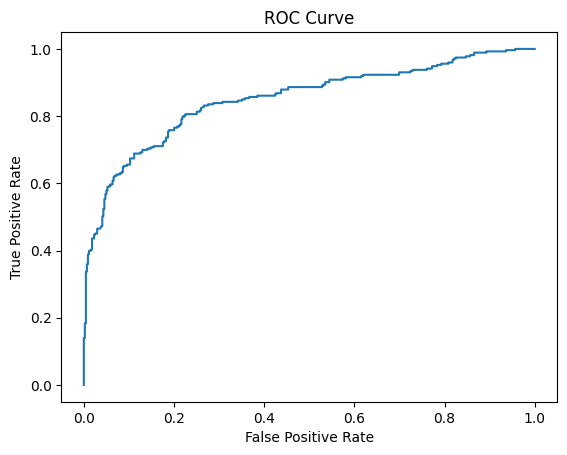

In [202]:
plt.plot(fpr, tpr)  ##basic roc curve
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

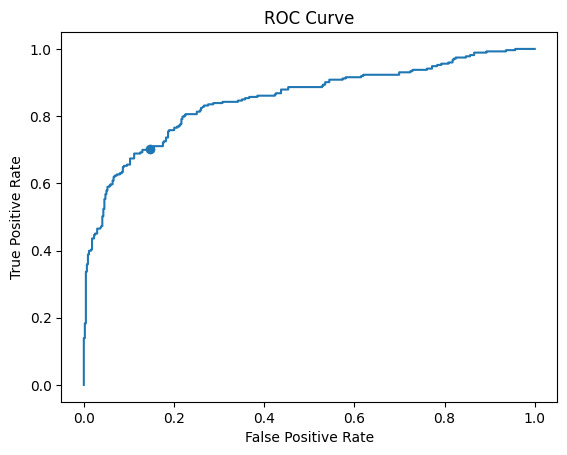

In [203]:
plt.plot(fpr, tpr)   ###ROC curve + threshold 0.5

plt.scatter(FPR, TPR)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [204]:
print("FPR:", FPR)
print("TPR:", TPR)

FPR: 0.14578587699316628
TPR: 0.7032967032967034


In [205]:
cv_probabilities[:10, 1]

array([0.1004924 , 0.20542088, 0.67870941, 0.63336664, 0.72228101,
       0.10771647, 0.10974919, 0.79276543, 0.16903114, 0.47497366])

In [206]:
pred_05 = (cv_probabilities[:, 1] >= 0.5)
pred_03 = (cv_probabilities[:, 1] >= 0.3)

print(pred_05.sum())
print(pred_03.sum())

256
333


In [207]:
pred_03 = (cv_probabilities[:, 1] >= 0.3)

In [208]:
cm_03 = confusion_matrix(y_train, pred_03)

print(cm_03)

[[328 111]
 [ 51 222]]


In [209]:
TN, FP, FN, TP = cm_03.ravel()

TPR_03 = TP / (TP + FN)
FPR_03 = FP / (FP + TN)

print("TPR:", TPR_03)
print("FPR:", FPR_03)

TPR: 0.8131868131868132
FPR: 0.2528473804100228


In [210]:
precision_03 = TP / (TP + FP)

print("Precision:", precision_03)

Precision: 0.6666666666666666


In [211]:
recall_03 = TPR_03

f1_03 = 2 * (precision_03 * recall_03) / (precision_03 + recall_03)

print("F1:", f1_03)

F1: 0.7326732673267325


In [212]:
FPR_03 = FP / (FP + TN)

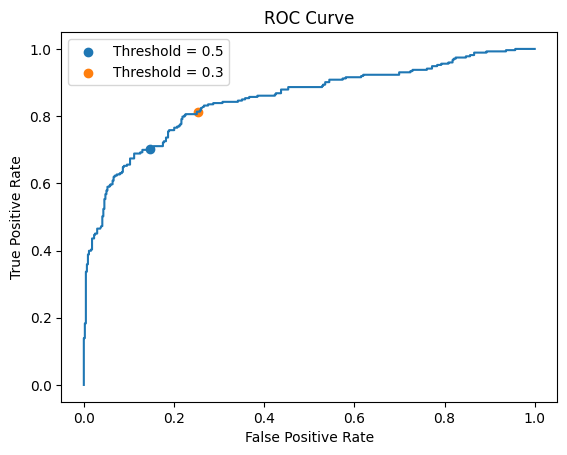

In [213]:
plt.plot(fpr, tpr)     ###ROC curve + thresholds 0.5 and 0.3

plt.scatter(FPR, TPR, label="Threshold = 0.5")
plt.scatter(FPR_03, TPR_03, label="Threshold = 0.3")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [214]:
from sklearn.metrics import auc


In [215]:
roc_auc_from_curve = auc(fpr, tpr)

print("AUC from ROC curve:", roc_auc_from_curve)

AUC from ROC curve: 0.8506470750206514


## **8.2 Decision Tree**

In [216]:
from sklearn.tree import DecisionTreeClassifier

In [217]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [218]:
dt_pipeline=Pipeline([("preprocessor", preprocessor),("model",dt_model)])

In [219]:
dt_cv_scores= cross_val_score(dt_pipeline, X_train, y_train,cv=5,scoring="accuracy")

In [220]:
dt_cv_scores.mean()

np.float64(0.778193637348567)

In [221]:
dt_cv_predictions=cross_val_predict(dt_pipeline, X_train,y_train,cv=5)

In [222]:
from sklearn.metrics import confusion_matrix

In [223]:
dt_cm=confusion_matrix(y_train,dt_cv_predictions)
dt_cm

array([[361,  78],
       [ 80, 193]])

In [224]:
from sklearn.metrics import recall_score

In [225]:
dt_recall=recall_score(y_train,dt_cv_predictions)
print("Recall:", dt_recall)

Recall: 0.706959706959707


In [226]:
from sklearn.metrics import precision_score

In [227]:
dt_precision_score= precision_score(y_train,dt_cv_predictions)
print("Precision:", dt_precision_score)

Precision: 0.7121771217712177


In [228]:
from sklearn.metrics import f1_score

In [229]:
dt_f1=f1_score(y_train,dt_cv_predictions)
print("F1:", dt_f1)

F1: 0.7095588235294118


In [230]:
from sklearn.metrics import classification_report

In [231]:
print(classification_report(y_train, dt_cv_predictions))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       439
           1       0.71      0.71      0.71       273

    accuracy                           0.78       712
   macro avg       0.77      0.76      0.77       712
weighted avg       0.78      0.78      0.78       712



**ROC-AUC**

In [232]:
dt_cv_probabilities = cross_val_predict(
    dt_pipeline,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)

In [233]:
from sklearn.metrics import roc_auc_score

In [234]:
dt_auc = roc_auc_score(
    y_train,
    dt_cv_probabilities[:, 1]
)

print("Decision Tree ROC-AUC:", dt_auc)

Decision Tree ROC-AUC: 0.7679040776990663


In [235]:
from sklearn.metrics import roc_curve

In [236]:
dt_fpr, dt_tpr, dt_thresholds = roc_curve(
    y_train,
    dt_cv_probabilities[:, 1]
)

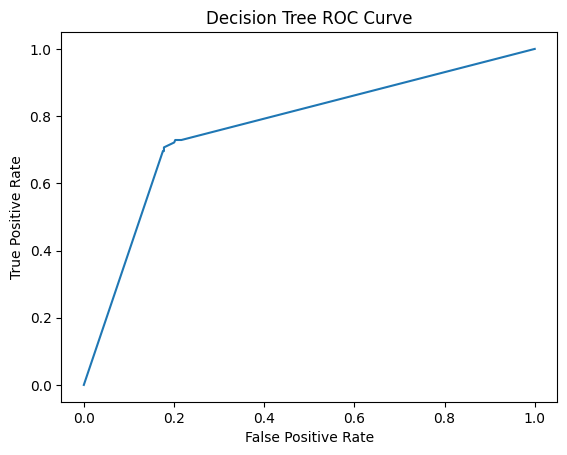

In [237]:
import matplotlib.pyplot as plt

plt.plot(dt_fpr, dt_tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")

plt.show()

**8.2.1 Hyperparameter Tuning**

The maximum depth of the Decision Tree was varied to examine its effect on cross-validation performance. Mean five-fold cross-validation accuracy was used to compare the candidate values.

In [238]:
depths = [2, 3, 4, 5, 6, 8, 10]

In [239]:
dt_depth_results = []  ##create an empty list to store our results:Because we'll eventually have something like:

#depth = 2  → accuracy = ...
#depth = 3  → accuracy = ...
#depth = 4  → accuracy = ...

In [240]:
for depth in depths:
    print(depth)

2
3
4
5
6
8
10


In [241]:
for depth in depths:
    dt_model_temp = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

In [242]:
for depth in depths:
    dt_model_temp = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt_pipeline_temp = Pipeline([
        ("preprocessor", preprocessor),
        ("model", dt_model_temp)
    ])

In [243]:
dt_scores_temp = cross_val_score(
    dt_pipeline_temp,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

In [244]:
for depth in depths:                                                         ###complete loop
    dt_model_temp = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt_pipeline_temp = Pipeline([
        ("preprocessor", preprocessor),
        ("model", dt_model_temp)
    ])

    dt_scores_temp = cross_val_score(
        dt_pipeline_temp,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    dt_depth_results.append(
        (depth, dt_scores_temp.mean())
    )


In [245]:
dt_depth_results

[(2, np.float64(0.7949965527430317)),
 (3, np.float64(0.8076627597754358)),
 (4, np.float64(0.8174825174825175)),
 (5, np.float64(0.816083916083916)),
 (6, np.float64(0.8104895104895105)),
 (8, np.float64(0.8189303654092388)),
 (10, np.float64(0.8063134049049541))]

In [246]:
depth_values = [x[0] for x in dt_depth_results]
accuracy_values = [x[1] for x in dt_depth_results]

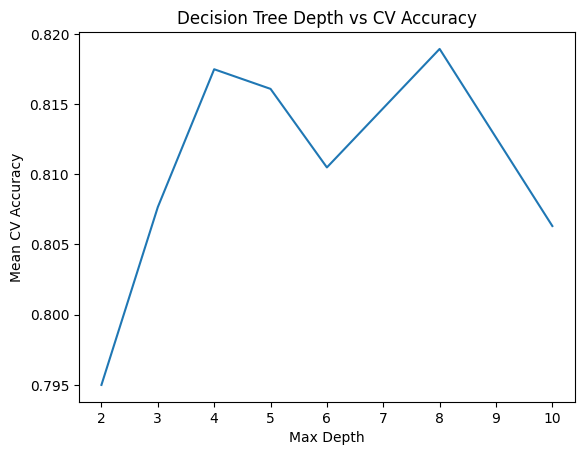

In [247]:
plt.plot(depth_values, accuracy_values)

plt.xlabel("Max Depth")
plt.ylabel("Mean CV Accuracy")
plt.title("Decision Tree Depth vs CV Accuracy")

plt.show()

In [248]:
best_accuracy = max(accuracy_values)

print("Best CV accuracy:", best_accuracy)

Best CV accuracy: 0.8189303654092388


In [249]:
best_index = accuracy_values.index(best_accuracy)

print("Best index:", best_index)

Best index: 5


In [250]:
best_depth = depth_values[best_index]

print("Best depth:", best_depth)

Best depth: 8


In [251]:
best_dt_model = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

In [252]:
best_dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_dt_model)
])

In [253]:
best_dt_cv_predictions = cross_val_predict(
    best_dt_pipeline,
    X_train,
    y_train,
    cv=5
)

In [254]:
best_dt_cm = confusion_matrix(
    y_train,
    best_dt_cv_predictions
)

print(best_dt_cm)

[[395  44]
 [ 85 188]]


In [255]:
best_dt_recall = recall_score(
    y_train,
    best_dt_cv_predictions
)

print("Recall:", best_dt_recall)

Recall: 0.6886446886446886


In [256]:
best_dt_precision = precision_score(
    y_train,
    best_dt_cv_predictions
)

print("Precision:", best_dt_precision)

Precision: 0.8103448275862069


In [257]:
best_dt_f1 = f1_score(
    y_train,
    best_dt_cv_predictions
)

print("F1:", best_dt_f1)

F1: 0.7445544554455445


**ROC-AUC**

In [258]:
best_dt_cv_probabilities = cross_val_predict(
    best_dt_pipeline,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)

In [259]:
best_dt_auc = roc_auc_score(
    y_train,
    best_dt_cv_probabilities[:, 1]
)

print("Tuned Decision Tree ROC-AUC:", best_dt_auc)

Tuned Decision Tree ROC-AUC: 0.8007751549892781


In [260]:
best_dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=8, random_state=42))])

**8.2.3 Feature Importance**

Feature importance was examined to understand which predictors contributed most to the tuned Decision Tree's predictions.

Two approaches were considered:

* Impurity-based feature importance, calculated from the fitted Decision Tree.
* Permutation importance, which measures the change in model performance after randomly permuting each feature.

In [261]:
feature_names = best_dt_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

print(feature_names)

['num__pclass' 'num__age' 'num__sibsp' 'num__parch' 'num__fare'
 'cat__sex_female' 'cat__sex_male' 'cat__embarked_C' 'cat__embarked_Q'
 'cat__embarked_S']


In [262]:
feature_importances = best_dt_pipeline.named_steps[
    "model"
].feature_importances_

print(feature_importances)

[0.14184147 0.18805604 0.01038001 0.00665054 0.20645098 0.41722496
 0.         0.         0.         0.02939599]


In [263]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df)

           feature  importance
5  cat__sex_female    0.417225
4        num__fare    0.206451
1         num__age    0.188056
0      num__pclass    0.141841
9  cat__embarked_S    0.029396
2       num__sibsp    0.010380
3       num__parch    0.006651
6    cat__sex_male    0.000000
7  cat__embarked_C    0.000000
8  cat__embarked_Q    0.000000


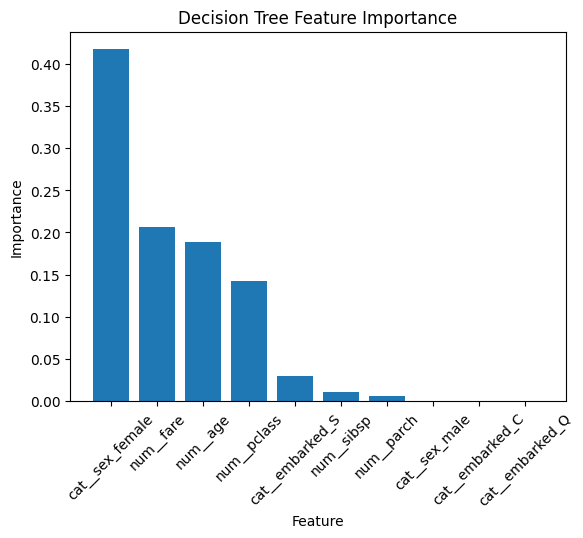

In [264]:
plt.bar(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Decision Tree Feature Importance")

plt.xticks(rotation=45)
plt.show()

**8.2.4 Permutation Importance**

Permutation importance was used as a complementary feature-importance measure. Each predictor is randomly permuted repeatedly, and the resulting change in model accuracy is used to estimate its contribution to predictive performance.

Unlike impurity-based importance, permutation importance evaluates the effect of disrupting each input feature on the model's predictive performance.

In [265]:
from sklearn.inspection import permutation_importance

In [266]:
perm_importance = permutation_importance(
    best_dt_pipeline,
    X_train,
    y_train,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

In [267]:
print(perm_importance.importances_mean)

[0.12598315 0.22261236 0.1008427  0.00575843 0.00617978 0.12064607
 0.03679775]


In [268]:
print(perm_importance.importances_std)

[0.01201725 0.01070092 0.00524762 0.00146634 0.00252809 0.00363273
 0.00420411]


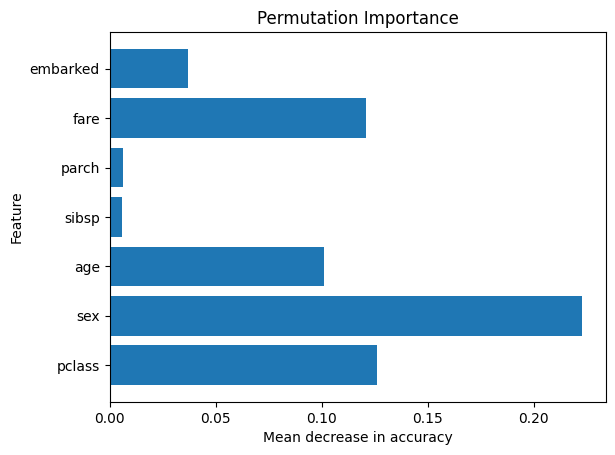

In [269]:
plt.barh(
    features,
    perm_importance.importances_mean
)

plt.xlabel("Mean decrease in accuracy")
plt.ylabel("Feature")
plt.title("Permutation Importance")

plt.show()

### **8.3 Random Forest**

Random Forest was evaluated as an ensemble tree-based classification model. A baseline model was first assessed using five-fold cross-validation, followed by sequential tuning of the number of trees and maximum tree depth.

In [270]:
from sklearn.ensemble import RandomForestClassifier

In [271]:
rf_model = RandomForestClassifier(               ###simple rf model, will later use customized parameters
    n_estimators=100,
    random_state=42
)

In [272]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

In [273]:
rf_cv_predictions = cross_val_predict(
    rf_pipeline,
    X_train,
    y_train,
    cv=5
)

In [274]:
rf_cm = confusion_matrix(
    y_train,
    rf_cv_predictions
)

print(rf_cm)

[[368  71]
 [ 78 195]]


In [275]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [276]:
print("Accuracy:", accuracy_score(y_train, rf_cv_predictions))
print("Precision:", precision_score(y_train, rf_cv_predictions))
print("Recall:", recall_score(y_train, rf_cv_predictions))
print("F1:", f1_score(y_train, rf_cv_predictions))

Accuracy: 0.7907303370786517
Precision: 0.7330827067669173
Recall: 0.7142857142857143
F1: 0.7235621521335807


In [277]:
rf_cv_probabilities = cross_val_predict(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)

In [278]:
rf_auc = roc_auc_score(
    y_train,
    rf_cv_probabilities[:, 1]
)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.8518903268333792


**8.3.1 Tuning the Number of Trees**

The number of trees (n_estimators) was varied to examine whether increasing the size of the Random Forest improved mean five-fold cross-validation accuracy.

In [279]:
n_trees = [50, 100, 200, 300]

In [280]:
rf_tree_results = []

for n in n_trees:
    rf_model_temp = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    rf_pipeline_temp = Pipeline([
        ("preprocessor", preprocessor),
        ("model", rf_model_temp)
    ])

    scores = cross_val_score(
        rf_pipeline_temp,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    rf_tree_results.append(
        (n, scores.mean())
    )

print(rf_tree_results)

[(50, np.float64(0.7922682950851965)), (100, np.float64(0.7908401457697234)), (200, np.float64(0.7894710922879936)), (300, np.float64(0.790879542992219))]


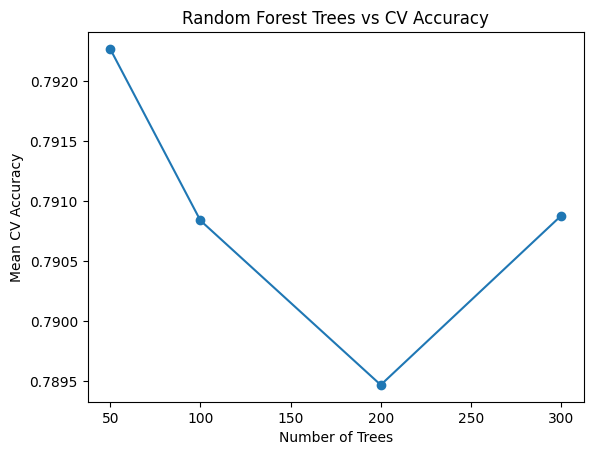

In [322]:
tree_counts = [result[0] for result in rf_tree_results]
tree_accuracies = [result[1] for result in rf_tree_results]

plt.plot(tree_counts, tree_accuracies, marker="o")
plt.xlabel("Number of Trees")
plt.ylabel("Mean CV Accuracy")
plt.title("Random Forest Trees vs CV Accuracy")
plt.show()

**8.3.2 Tuning Maximum Depth**

After evaluating the number of trees, the maximum tree depth **(max_depth)** was varied while keeping the number of trees fixed at the best-performing value from the previous tuning step.

In [281]:
rf_depths = [3, 5, 7, 10, None]   ###None means the trees are allowed to grow without a maximum depth restriction.

In [282]:
rf_depth_results = []                                 ###tuning another parameter max_dept, we get the best result from n_estimators=50, So we kept it

for depth in rf_depths:
    rf_model_temp = RandomForestClassifier(
        n_estimators=50,
        max_depth=depth,
        random_state=42
    )

    rf_pipeline_temp = Pipeline([
        ("preprocessor", preprocessor),
        ("model", rf_model_temp)
    ])

    scores = cross_val_score(
        rf_pipeline_temp,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    rf_depth_results.append(
        (depth, scores.mean())
    )

print(rf_depth_results)

[(3, np.float64(0.8174431202600217)), (5, np.float64(0.8188909681867429)), (7, np.float64(0.8189008174923668)), (10, np.float64(0.8076923076923077)), (None, np.float64(0.7922682950851965))]


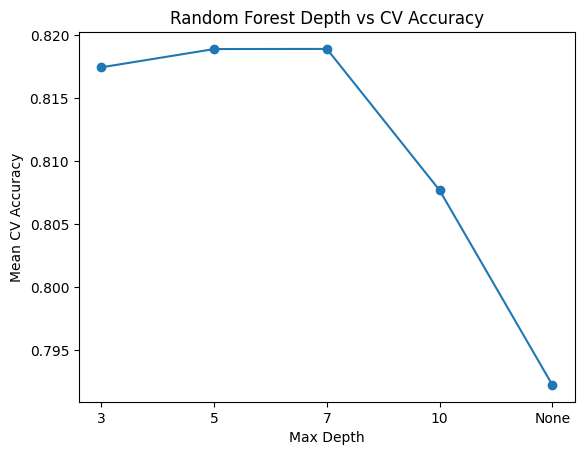

In [323]:
depth_labels = [
    "3", "5", "7", "10", "None"
]

depth_accuracies = [
    result[1] for result in rf_depth_results
]

plt.plot(depth_labels, depth_accuracies, marker="o")
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Accuracy")
plt.title("Random Forest Depth vs CV Accuracy")
plt.show()

**8.3.3 Tuned Random Forest**

Based on the sequential hyperparameter evaluation, the Random Forest was configured with 50 trees and a maximum depth of 5 for the final candidate model.

In [283]:
best_rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    random_state=42
)

best_rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_rf_model)
])

In [284]:
best_rf_cv_predictions = cross_val_predict(
    best_rf_pipeline,
    X_train,
    y_train,
    cv=5
)

**Tuned model evaluation**

In [285]:
print("Accuracy:", accuracy_score(y_train, best_rf_cv_predictions))
print("Precision:", precision_score(y_train, best_rf_cv_predictions))
print("Recall:", recall_score(y_train, best_rf_cv_predictions))
print("F1:", f1_score(y_train, best_rf_cv_predictions))

Accuracy: 0.8188202247191011
Precision: 0.8157894736842105
Recall: 0.6813186813186813
F1: 0.7425149700598802


In [286]:
best_rf_cv_probabilities = cross_val_predict(
    best_rf_pipeline,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)

best_rf_auc = roc_auc_score(
    y_train,
    best_rf_cv_probabilities[:, 1]
)

print("Tuned Random Forest ROC-AUC:", best_rf_auc)

Tuned Random Forest ROC-AUC: 0.8665339975134964


**8.4 K-Nearest Neighbors (KNN)**

K-Nearest Neighbors (KNN) was evaluated as a distance-based classification algorithm. The model was first assessed using five-fold cross-validation with the default value of n_neighbors=5, followed by tuning of the number of neighbors.

In [288]:
from sklearn.neighbors import KNeighborsClassifier

In [289]:
knn_model= KNeighborsClassifier(n_neighbors=5)

In [290]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", knn_model)
])

In [291]:
knn_cv_predictions = cross_val_predict(
    knn_pipeline,
    X_train,
    y_train,
    cv=5
)

In [292]:
print("Accuracy:", accuracy_score(y_train, knn_cv_predictions))
print("Precision:", precision_score(y_train, knn_cv_predictions))
print("Recall:", recall_score(y_train, knn_cv_predictions))
print("F1:", f1_score(y_train, knn_cv_predictions))

Accuracy: 0.8103932584269663
Precision: 0.776
Recall: 0.7106227106227107
F1: 0.7418738049713193


In [293]:
knn_cv_probabilities = cross_val_predict(
    knn_pipeline,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)

In [294]:
knn_auc = roc_auc_score(
    y_train,
    knn_cv_probabilities[:, 1]
)

print("KNN ROC-AUC:", knn_auc)

KNN ROC-AUC: 0.8491409880931522


**8.4.1 Hyperparameter Tuning**

The number of neighbors (n_neighbors) was varied to examine its effect on mean five-fold cross-validation accuracy.

In [295]:
knn_values = [3, 5, 7, 9, 11]

In [296]:
knn_results = []

for k in knn_values:
    knn_model_temp = KNeighborsClassifier(
        n_neighbors=k
    )

    knn_pipeline_temp = Pipeline([
        ("preprocessor", preprocessor),
        ("model", knn_model_temp)
    ])

    scores = cross_val_score(
        knn_pipeline_temp,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    knn_results.append(
        (k, scores.mean())
    )

print(knn_results)

[(3, np.float64(0.8048261597557372)), (5, np.float64(0.8104698118782625)), (7, np.float64(0.8174726681768935)), (9, np.float64(0.8174825174825175)), (11, np.float64(0.8160543681670444))]


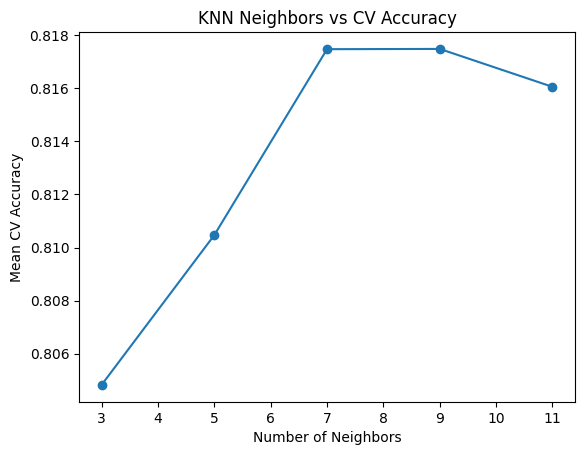

In [324]:
knn_values_plot = [result[0] for result in knn_results]
knn_accuracies = [result[1] for result in knn_results]

plt.plot(
    knn_values_plot,
    knn_accuracies,
    marker="o"
)

plt.xlabel("Number of Neighbors")
plt.ylabel("Mean CV Accuracy")
plt.title("KNN Neighbors vs CV Accuracy")
plt.show()

**8.4.2 Tuned KNN**

The KNN model was refitted with the number of neighbors that produced the highest mean cross-validation accuracy during hyperparameter evaluation.

In [297]:
best_knn_model = KNeighborsClassifier(
    n_neighbors=9
)

best_knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_knn_model)
])

In [298]:
best_knn_cv_predictions = cross_val_predict(
    best_knn_pipeline,
    X_train,
    y_train,
    cv=5
)

In [299]:
knn_accuracy = accuracy_score(y_train, best_knn_cv_predictions)
knn_precision = precision_score(y_train, best_knn_cv_predictions)
knn_recall = recall_score(y_train, best_knn_cv_predictions)
knn_f1 = f1_score(y_train, best_knn_cv_predictions)

print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1:", knn_f1)

Accuracy: 0.8174157303370787
Precision: 0.8016877637130801
Recall: 0.6959706959706959
F1: 0.7450980392156863


In [300]:
best_knn_cv_probabilities = cross_val_predict(
    best_knn_pipeline,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)

best_knn_auc = roc_auc_score(
    y_train,
    best_knn_cv_probabilities[:, 1]
)

print("ROC-AUC:", best_knn_auc)

ROC-AUC: 0.8646273999349171


**8.5 Gradient Boosting**

Gradient Boosting was evaluated as a sequential ensemble learning algorithm. A baseline model was first assessed using five-fold cross-validation, followed by sequential tuning of the number of boosting stages and learning rate.

In [301]:
from sklearn.ensemble import GradientBoostingClassifier

In [302]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

In [303]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", gb_model)
])

In [304]:
gb_cv_predictions = cross_val_predict(
    gb_pipeline,
    X_train,
    y_train,
    cv=5
)

In [305]:
gb_accuracy = accuracy_score(y_train, gb_cv_predictions)
gb_precision = precision_score(y_train, gb_cv_predictions)
gb_recall = recall_score(y_train, gb_cv_predictions)
gb_f1 = f1_score(y_train, gb_cv_predictions)

print("Accuracy:", gb_accuracy)
print("Precision:", gb_precision)
print("Recall:", gb_recall)
print("F1:", gb_f1)

Accuracy: 0.8160112359550562
Precision: 0.8141592920353983
Recall: 0.673992673992674
F1: 0.7374749498997996


In [306]:
gb_cv_probabilities = cross_val_predict(
    gb_pipeline,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)

gb_auc = roc_auc_score(
    y_train,
    gb_cv_probabilities[:, 1]
)

print("ROC-AUC:", gb_auc)

ROC-AUC: 0.8730297796357022


**8.5.1 Tuning the Number of Estimators**

The number of boosting stages (n_estimators) was varied to examine its effect on mean five-fold cross-validation accuracy.

In [307]:
gb_estimators = [50, 100, 150, 200]

In [308]:
gb_results = []

for n in gb_estimators:
    gb_model_temp = GradientBoostingClassifier(
        n_estimators=n,
        random_state=42
    )

    gb_pipeline_temp = Pipeline([
        ("preprocessor", preprocessor),
        ("model", gb_model_temp)
    ])

    scores = cross_val_score(
        gb_pipeline_temp,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    gb_results.append(
        (n, scores.mean())
    )

print(gb_results)

[(50, np.float64(0.8132965625923372)), (100, np.float64(0.8161036146951641)), (150, np.float64(0.8133261105092091)), (200, np.float64(0.8175613119275091))]


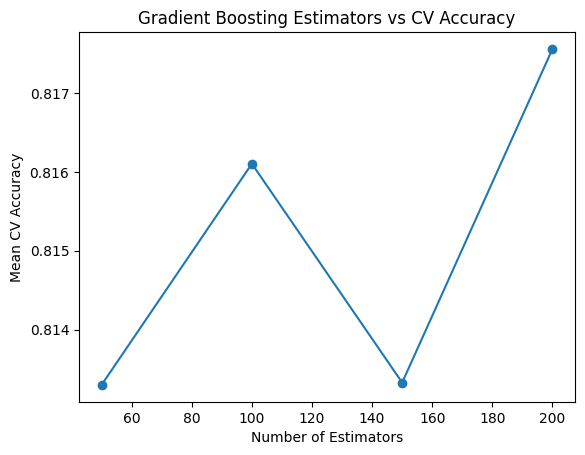

In [325]:
estimator_values = [result[0] for result in gb_results]
estimator_accuracies = [result[1] for result in gb_results]

plt.plot(
    estimator_values,
    estimator_accuracies,
    marker="o"
)

plt.xlabel("Number of Estimators")
plt.ylabel("Mean CV Accuracy")
plt.title("Gradient Boosting Estimators vs CV Accuracy")
plt.show()

**8.5.2 Tuning the Learning Rate**

The learning rate was subsequently varied while keeping the number of estimators fixed at 200, based on the preceding tuning step.

In [309]:
gb_learning_rates = [0.01, 0.05, 0.1, 0.2]

In [310]:
gb_lr_results = []

for lr in gb_learning_rates:
    gb_model_temp = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=lr,
        random_state=42
    )

    gb_pipeline_temp = Pipeline([
        ("preprocessor", preprocessor),
        ("model", gb_model_temp)
    ])

    scores = cross_val_score(
        gb_pipeline_temp,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    gb_lr_results.append(
        (lr, scores.mean())
    )

print(gb_lr_results)

[(0.01, np.float64(0.8189205161036147)), (0.05, np.float64(0.8161331626120358)), (0.1, np.float64(0.8175613119275091)), (0.2, np.float64(0.8105289077120063))]


**8.5.3 Tuned Gradient Boosting**

The Gradient Boosting model was configured using the hyperparameter values selected during the sequential tuning process.

In [311]:
best_gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.01,
    random_state=42
)

best_gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_gb_model)
])

In [312]:
best_gb_cv_predictions = cross_val_predict(
    best_gb_pipeline,
    X_train,
    y_train,
    cv=5
)

In [313]:
gb_accuracy = accuracy_score(y_train, best_gb_cv_predictions)
gb_precision = precision_score(y_train, best_gb_cv_predictions)
gb_recall = recall_score(y_train, best_gb_cv_predictions)
gb_f1 = f1_score(y_train, best_gb_cv_predictions)

print("Accuracy:", gb_accuracy)
print("Precision:", gb_precision)
print("Recall:", gb_recall)
print("F1:", gb_f1)

Accuracy: 0.8188202247191011
Precision: 0.8461538461538461
Recall: 0.6446886446886447
F1: 0.7318087318087318


In [314]:
best_gb_cv_probabilities = cross_val_predict(
    best_gb_pipeline,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)

best_gb_auc = roc_auc_score(
    y_train,
    best_gb_cv_probabilities[:, 1]
)

print("ROC-AUC:", best_gb_auc)

ROC-AUC: 0.8661501748062113


**8.6 Model Comparison and Final Model Selection**

The candidate models were compared using cross-validation performance across accuracy, precision, recall, F1-score, and ROC-AUC.

Gradient Boosting achieved the highest ROC-AUC among the evaluated baseline models (0.873) while maintaining competitive accuracy and precision. Although the tuned Gradient Boosting model achieved slightly higher accuracy and precision, its ROC-AUC, recall, and F1-score were lower than those of the baseline Gradient Boosting model.

Therefore, the baseline Gradient Boosting model was selected as the final candidate based primarily on its cross-validated ROC-AUC and overall performance profile.

The held-out test set remained untouched during model comparison and hyperparameter tuning.

In [326]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "Accuracy": [
        0.7964,
        0.8189,
        0.8188,
        0.8174,
        0.8160,
        0.8188
    ],
    "Precision": [
        0.7500,
        0.8103,
        0.8158,
        0.8017,
        0.8142,
        0.8462
    ],
    "Recall": [
        0.7033,
        0.6886,
        0.6813,
        0.6960,
        0.6740,
        0.6447
    ],
    "F1": [
        0.7259,
        0.7446,
        0.7425,
        0.7451,
        0.7375,
        0.7318
    ],
    "ROC-AUC": [
        0.8506,
        0.8010,
        0.8670,
        0.8650,
        0.8730,
        0.8660
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.7964,0.7500,0.7033,0.7259,0.8506
1,Decision Tree,0.8189,0.8103,0.6886,0.7446,0.8010
2,Random Forest,0.8188,0.8158,0.6813,0.7425,0.8670
3,KNN,0.8174,0.8017,0.6960,0.7451,0.8650
4,Gradient Boosting,0.8160,0.8142,0.6740,0.7375,0.8730
5,Tuned Gradient Boosting,0.8188,0.8462,0.6447,0.7318,0.8660


In [327]:
percentage_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

model_comparison[percentage_columns] = (
    model_comparison[percentage_columns] * 100
).round(2)

model_comparison["ROC-AUC"] = model_comparison["ROC-AUC"].round(3)

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,79.64,75.00,70.33,72.59,0.851
1,Decision Tree,81.89,81.03,68.86,74.46,0.801
2,Random Forest,81.88,81.58,68.13,74.25,0.867
3,KNN,81.74,80.17,69.60,74.51,0.865
4,Gradient Boosting,81.60,81.42,67.40,73.75,0.873
5,Tuned Gradient Boosting,81.88,84.62,64.47,73.18,0.866


## **Model Comparison**
The five candidate models showed broadly similar cross-validation performance, with differences across individual evaluation metrics. The Decision Tree achieved the highest cross-validation accuracy, while KNN achieved the highest F1-score. The baseline Gradient Boosting model achieved the highest ROC-AUC (0.873), indicating the strongest overall discrimination among the evaluated models.

The tuned Gradient Boosting model achieved slightly higher accuracy and precision than the baseline model but showed lower recall, F1-score, and ROC-AUC. Therefore, the baseline Gradient Boosting model was selected as the final candidate based primarily on its highest cross-validated ROC-AUC and overall performance profile.

## **8.7 Final Evaluation on the Held-Out Test Set**

The selected Gradient Boosting model was fitted using the complete training set and evaluated once on the previously untouched test set.

This provides an estimate of model performance on unseen data.

In [315]:
final_model = gb_pipeline

final_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [316]:
y_test_pred = final_model.predict(X_test)

In [317]:
from sklearn.metrics import accuracy_score  ###Accuracy on the unseen test set

test_accuracy = accuracy_score(               ###accuracy_score() compares: y_test → the actual outcomes and y_test_pred → the model's predictions and calculates: How many of the 179 passengers did the model classify correctly?
    y_test,
    y_test_pred
)

print(test_accuracy)

0.7988826815642458


In [318]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_test_pred
)

print(cm)

[[98 12]
 [24 45]]


In [319]:
from sklearn.metrics import precision_score, recall_score, f1_score

test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1-score:", test_f1)

Precision: 0.7894736842105263
Recall: 0.6521739130434783
F1-score: 0.7142857142857143


In [320]:
y_test_prob = final_model.predict_proba(X_test)[:, 1]

In [321]:
from sklearn.metrics import roc_auc_score

test_auc = roc_auc_score(
    y_test,
    y_test_prob
)

print("Test ROC-AUC:", test_auc)

Test ROC-AUC: 0.8180500658761529


## **Final Model Summary**

The baseline Gradient Boosting model was selected based primarily on its cross-validated ROC-AUC and overall performance profile. When evaluated on the previously untouched test set, the model achieved 79.89% accuracy and a ROC-AUC of 0.818.

The difference between cross-validation and test performance indicates some expected variation in performance on unseen data. The test set was used only for the final evaluation and was not used for model selection or further tuning.